In [3]:
import sys
sys.path.append('..')
sys.path.append('/Users/shangguan/Downloads/SAGAN-MCMC/')

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

from astropy.modeling import models, fitting
import galspec
import galspec_mcmc

import glob
from astropy.table import Table
import os
import pickle
from scipy.interpolate import interp1d

from galspec.utils import line_label_dict, line_wave_dict
import json

from scipy.interpolate import InterpolatedUnivariateSpline
from matplotlib.colors import Normalize

from astropy.coordinates import SkyCoord
import astropy.units as u

import matplotlib as mpl
mpl.rc("xtick", direction="in", labelsize=16)
mpl.rc("ytick", direction="in", labelsize=16)
mpl.rc("xtick.major", width=1., size=8)
mpl.rc("ytick.major", width=1., size=8)
mpl.rc("xtick.minor", width=1., size=5)
mpl.rc("ytick.minor", width=1., size=5)

ls_km = 2.99792e5 # km/s

def jy2erg(y,wavelength):
    
    # converting energy in Jy into erg/s/cm^2/A
    # wavelength in anstrom
    cont=3.33564095*10**4
    x=y/(cont*wavelength**2)

    return(x)

def erg2jy(x,wavelength):
    
    # converting energy in erg/s/cm^2/A into Jy
    # wavelength in anstrom
    cont=3.33564095*10**4
    y=x*(cont*wavelength**2)

    return(y)

/Users/shangguan/Downloads/SAGAN-MCMC/sagan_mcmc/stellar_continuum.py:31: SyntaxWarning: invalid escape sequence '\s'
  spec = pd.read_csv(f'{package_path}{splitter}data{splitter}{file_name}', sep='\s+', comment='#', header=None, names=['lam', 'Flux'])


1021.222


/Users/shangguan/Softwares/miniforge3/envs/norm/lib/python3.13/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 6000/6000 [01:14<00:00, 80.37it/s]


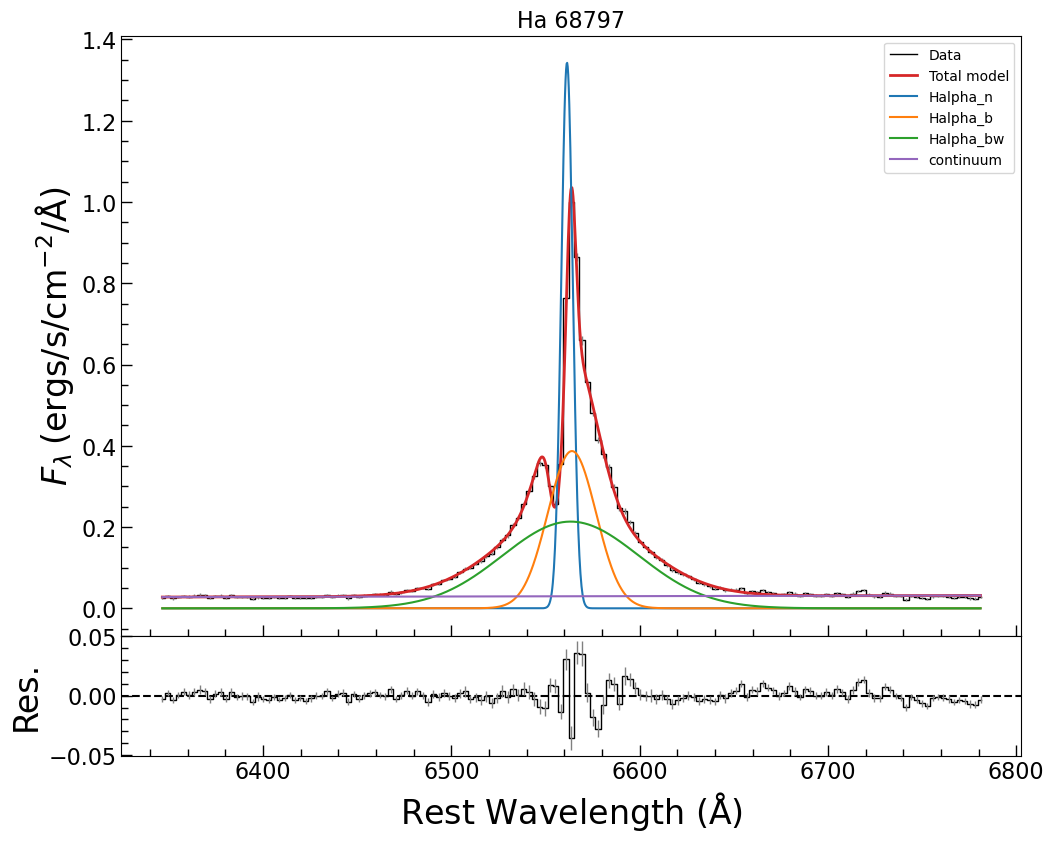

In [5]:
ha_spec_path=glob.glob(f'data/jades-gdn198-v4_g395m-f290lp_1181_68797.spec.fits')[0]

with fits.open(ha_spec_path) as f:
    spec_data=f[1].data
    spec_hdr=f[1].header
    print(spec_hdr['XPOSURE'])
    
z=5.041321301235969

dv_line_ha=10000

ha_wv=line_wave_dict['Halpha']
wv_min_ha, wv_max_ha=ha_wv-ha_wv*dv_line_ha/ls_km, ha_wv+ha_wv*dv_line_ha/ls_km

flux_ha=spec_data['flux']
flux_err_ha=spec_data['err']
r_list=spec_data['R']

flux_ha=jy2erg(flux_ha*1e-6, spec_data['wave']*1e4)
flux_err_ha=jy2erg(flux_err_ha*1e-6, spec_data['wave']*1e4)

wave_ha=spec_data['wave']*1e4/(1+z)

flux_use_ha=flux_ha[np.where((wave_ha>wv_min_ha) & (wave_ha<wv_max_ha))]
flux_err_use_ha=flux_err_ha[np.where((wave_ha>wv_min_ha) & (wave_ha<wv_max_ha))]
norm_scale=np.max(flux_use_ha)

flux_use_ha=flux_use_ha/norm_scale
flux_err_use_ha=flux_err_use_ha/norm_scale
wave_use_ha=wave_ha[np.where((wave_ha>wv_min_ha) & (wave_ha<wv_max_ha))]

# Constraints from fitting [OIII] doublets (actually triplets ......)
dv_n=-63.07126534907583
sigma_n_ha=138.97784115977535

bounds_sigma_n=(100,425)
fixed_n={'dv': True, 'sigma': True}

ha_n_model=galspec.Line_Gaussian(amplitude=1, wavec=line_wave_dict['Halpha'],\
                                name='Halpha_n', dv=dv_n, sigma=sigma_n_ha,\
                                bounds={'sigma': bounds_sigma_n}, fixed= fixed_n)

ha_b_model=galspec.Line_Gaussian(amplitude=0.5, wavec=line_wave_dict['Halpha'],\
                                name='Halpha_b', dv=dv_n, sigma=1000,\
                                bounds={'sigma': (425, None),'dv':(-200, 200)}, fixed={})

ha_bw_model=galspec.Line_Gaussian(amplitude=0.2, wavec=line_wave_dict['Halpha'],\
                                name='Halpha_bw', dv=dv_n, sigma=1500,\
                                bounds={'sigma': (425, None),'dv':(-200, 200)}, fixed={})

ha_abs_model=galspec.Line_Absorption(tau_0=1, wavec=line_wave_dict['Halpha'],\
                                    name='Halpha_abs', dv=-200, sigma=200, Cf=1,\
                                    bounds={'tau_0': (0, None), 'Cf': (0, 1), 'sigma': (130, None)}, fixed={})

cont_model=models.Polynomial1D(degree=1, c0=0, c1=0, name='continuum')

model_ha_abs_2g=(ha_n_model + ha_b_model + ha_bw_model)*ha_abs_model + cont_model
mcmc_abs_2g=galspec_mcmc.MCMC_Fit(model_ha_abs_2g, wave_use_ha, flux_use_ha, flux_err_use_ha, nwalkers=100)
samples_abs_2g, model_ha_fit_abs_2g, par_names_abs_2g=mcmc_abs_2g.fit()

# make plots
ax,axr=galspec.plot.plot_fit_new(wave_use_ha, flux_use_ha, model_ha_fit_abs_2g, weight=None, error=flux_err_use_ha)
ax.set_ylabel(r'$F_\lambda\:({\rm ergs/s/cm^{-2}/\AA})$', fontsize=24)
axr.set_xlabel(r'Rest Wavelength ($\mathrm{\AA}$)', fontsize=24)

ax.set_title(f'Ha 68797', fontsize=16)

ax.legend(fontsize=10, ncol=1)
plt.show()
#plt.savefig(saveroot+str(srcid)+'.png', dpi=300, bbox_inches='tight')

In [6]:
for m in model_ha_fit_abs_2g:
    print(m.__repr__())

<Line_Gaussian(amplitude=1.34301658, dv=-63.07126535, sigma=138.97784116, wavec=6562.819, name='Halpha_n')>
<Line_Gaussian(amplitude=0.38704162, dv=56.47693897, sigma=585.86837509, wavec=6562.819, name='Halpha_b')>
<Line_Gaussian(amplitude=0.21343229, dv=24.80940089, sigma=1657.56667255, wavec=6562.819, name='Halpha_bw')>
<Line_Absorption(tau_0=1.42920694, dv=-232.18047376, sigma=186.53560529, Cf=0.97584679, wavec=6562.819, name='Halpha_abs')>
<Polynomial1D(1, c0=-0.02905949, c1=0.00000895, name='continuum')>
